<a href="https://colab.research.google.com/github/Andoniadou-Lab/consensus_pituitary_atlas/blob/main/Figure_S8/Figure_S8_Gata2_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mounting Drive onto colab

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
np.random.seed(42)


# Plotting Gata2

In [4]:
gata2_results = pd.read_csv("/content/drive/MyDrive/pituitary_atlas/Unstructured/resubmission_files/assignmentsGonadotrophs.gata2_ckoGATA2_CKO_GATA2_CKO_vs_Control_limma3v3.csv")
#just keep where adj.P.Val < 0.05
gata2_results = gata2_results[gata2_results["adj.P.Val"] < 0.05]
#remove where starts with Gm or contains Rik
gata2_results = gata2_results[~gata2_results["genes"].str.startswith("Gm")]
gata2_results = gata2_results[~gata2_results["genes"].str.contains("Rik")]
gata2_results.shape

(47, 8)

In [5]:
gene_annotation = pd.read_csv("/content/drive/MyDrive/pituitary_atlas/Unstructured/perturbations/cpdb.csv")
#keep where category TF gene_annotation
gene_annotation = gene_annotation[gene_annotation["category"] == "TF"]
gata2_results["category"] = gata2_results["genes"].isin(gene_annotation["gene"])
#set to TF if True
gata2_results.loc[gata2_results["category"], "TF"] = "TF"
#change TF to "hormone_sec" if genes is Fshb, Chga, Pcsk1
hormone_sec = ["Fshb", "Chga", "Pcsk1"]
gata2_results.loc[gata2_results["genes"].isin(hormone_sec), "TF"] = "hormone_sec"

gata2_results["direction"] = np.where(gata2_results["logFC"] < 0, "pos", "neg")
#remove Gata2
gata2_results = gata2_results[gata2_results["genes"] != "Gata2"]
gata2_results

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,genes,category,TF,direction
0,Pcsk1,-2.043710,6.669942,-12.590105,2.415063e-12,3.720646e-08,17.835075,Pcsk1,False,hormone_sec,pos
1,Grem1,-5.170766,1.179786,-9.929094,3.560640e-10,2.742761e-06,9.174283,Grem1,False,NaN,pos
2,Serpine2,-2.307158,5.512935,-9.423532,1.011460e-09,5.194183e-06,12.219129,Serpine2,False,NaN,pos
3,Prkg1,-2.180835,7.237988,-8.633947,5.518600e-09,2.125489e-05,10.657660,Prkg1,False,NaN,pos
5,Phex,-2.366336,2.348072,-7.495621,7.364747e-08,1.891022e-04,7.679857,Phex,False,NaN,pos
7,Serpinb1a,-2.412216,1.099702,-6.871974,3.271396e-07,6.299891e-04,6.065897,Serpinb1a,False,NaN,pos
10,Frmpd1,-1.085185,4.758316,-6.602487,6.323807e-07,8.856780e-04,6.116701,Frmpd1,False,NaN,pos
11,Chga,-2.615186,8.626301,-6.536351,7.443698e-07,9.556467e-04,5.970201,Chga,False,hormone_sec,pos
12,Sez6l,2.556833,1.830153,6.058510,2.452179e-06,2.906021e-03,4.265470,Sez6l,False,NaN,neg
13,Speer4e1,-3.284133,-0.051288,-5.954848,3.185705e-06,3.505640e-03,2.915684,Speer4e1,False,NaN,pos


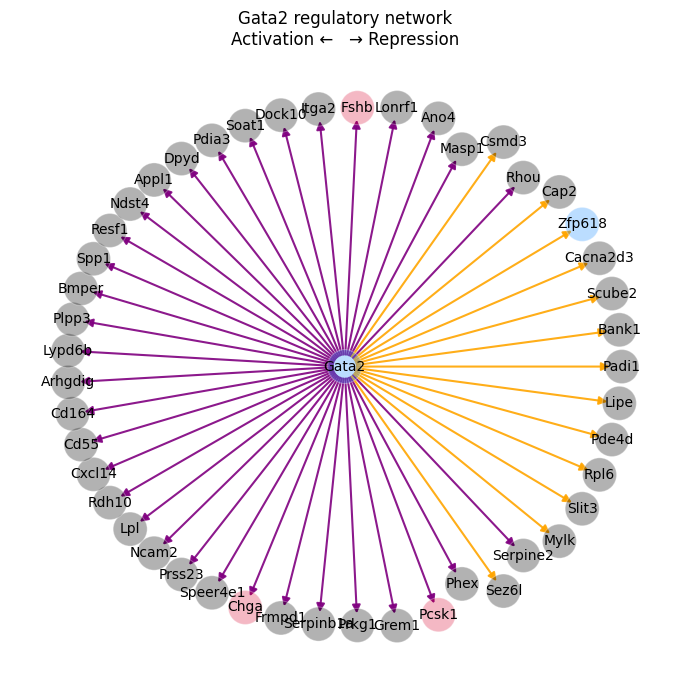

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()
central_gene = "Gata2"
G.add_node(central_gene, TF=True)

for _, row in gata2_results.iterrows():
    G.add_node(row["genes"], TF=row["TF"])
    G.add_edge(central_gene, row["genes"], direction=row["direction"])

# Separate genes by direction
pos_genes = gata2_results[gata2_results["direction"] == "pos"]["genes"].tolist()
neg_genes = gata2_results[gata2_results["direction"] == "neg"]["genes"].tolist()

# Build manual layout
pos = {}
pos[central_gene] = (0, 0)

# Vertical spacing
y_pos = np.linspace(-2.5, 2.5, len(pos_genes))
y_neg = np.linspace(-2.5, 2.5, len(neg_genes))

for gene, y in zip(pos_genes, y_pos):
    pos[gene] = (-0.5, y)   # LEFT = activation

for gene, y in zip(neg_genes, y_neg):
    pos[gene] = (0.5, y)    # RIGHT = repression

# Gently repel nodes, starting from manual layout
pos = nx.spring_layout(
    G,
    pos=pos,                 # use manual layout as initialization
    fixed=[central_gene],    # keep Gata2 anchored
    k=0.2,                   # small = subtle repulsion
    iterations=100,
    seed=42
)


# Colors
color_map = {
    "TF": "dodgerblue",
    "hormone_sec": "crimson",
    False: "black"
}

node_colors = [
    "dodgerblue" if n == central_gene else color_map.get(G.nodes[n].get("TF", False), "black")
    for n in G.nodes()
]

edge_colors = [
    "purple" if G.edges[e]["direction"] == "pos" else "orange"
    for e in G.edges()
]

# Plot
plt.figure(figsize=(7, 7))

nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=12,
    width=1.5,
    alpha=0.9
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=600,
    edgecolors="white",
    linewidths=0.8,
    alpha=0.3

)

nx.draw_networkx_labels(
    G, pos,
    font_size=10
)


plt.axis("off")
plt.title("Gata2 regulatory network\nActivation ←   → Repression", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pituitary_atlas/Unstructured/gata2_network.png", dpi=300)
plt.savefig("/content/drive/MyDrive/pituitary_atlas/Unstructured/gata2_network.svg")
plt.show()
